# 01 - Tomosipo Fundamentals

This notebook aims to build intuition for the CT geometry itself, as well as an understanding of how the Radon transform works, what a sinogram is and what it looks like, as well as how forward and backprojection are implemented in tomosipo. 

It is structured in two sections:

1. The original tomosipo tutorial notebooks copied over from https://github.com/cicwi/tomosipo 
2. My own project specific exploration of the package with the shepp-logan phantom which produces some baseline reconstructions, illustrates sparse-view artefacts, and aims to understand the errors within CT.

### Why this matters

The TFPnP paper uses TorchRadon as its CT backend, while the aim of the project is to reproduce it using LION, which is based on tomosipo/ASTRA. Before beginning to implement TFPnP, it's important to verify that the same physical operations (forward projection, backprojection, noise simulation, reconstruction) are working correctly.

#### Note

For the purposes of this exploration, the notebook was ran on CSD3 due to it's requirement of tomosipo.

In [1]:
import os
import astra
import tomosipo as ts
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(f"astra    : {astra.__version__}")
print(f"tomosipo : {ts.__version__}")
print(f"torch    : {torch.__version__}")
print(f"cuda     : {torch.cuda.is_available()}")
print(f"device   : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU'}")

# Create figure output directory if it does not exist
output_dir = Path("../figures/01")
output_dir.mkdir(parents=True, exist_ok=True)

astra    : 2.4.1
tomosipo : 0.7.0
torch    : 2.5.1+cu121
cuda     : True
device   : NVIDIA A100-SXM4-80GB


# Section 1 — Original Tomosipo Notebooks

This section consolidates `00_getting_started_google_colab.ipynb` and `sirt.ipynb` from the tomosipo repository with the aim of learning the tomosipo API using the original examples, before adapting anything for the project.

The only alterations made have been additions of comments throughout the code to aid with understanding, as well as minor changes to the markdown cells.

## 1.1 Getting Started — Minimal Geometry

The original notebook defines a minimal cone-beam geometry with default settings (unit cube, 20 angles).

ts.cone(
    angles=20,
    shape=(1, 1),
    size=(1.4142135623730951, 1.4142135623730951),
    src_orig_dist=2.8284271247461903,
    src_det_dist=2.8284271247461903,
)
ts.volume(
    shape=(1, 1, 1),
    pos=(0.0, 0.0, 0.0),
    size=(1.0, 1.0, 1.0),
)


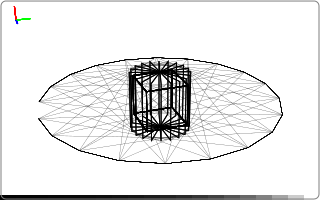

In [2]:
# Create 'unit' cone geometry
pg = ts.cone(angles=20, size=np.sqrt(2), cone_angle=0.5)
print(pg)

# Create volume geometry of a unit cube on the origin
vg = ts.volume()
print(vg)

# Display an animation of the acquisition geometry
ts.svg(pg, vg)

### Checking operator shapes

The operator A maps from image space (domain) to sinogram space (range). 

We want to verify the shapes and confirm that forward projection and backprojection work correctly.

In [3]:
# Create the forward operator
A = ts.operator(vg, pg)

# display domain and range shape
print("Domain shape:", A.domain_shape)
print("Range shape:", A.range_shape)

# create simple phantom using domain shape
phantom = np.zeros(A.domain_shape)

# set first plane to 1.0 so that the test case is simple to verify
phantom[0, :, :] = 1.0 

# apply forward operator to phantom
y = A(phantom)

# print projection shape
print("Projection shape:", y.shape)

# apply backprojection
x_back = A.T(y)

# print backprojection shape - should be the same as phantom shape
print("Backprojection shape:", x_back.shape)

Domain shape: (1, 1, 1)
Range shape: (1, 20, 1)


/rds/user/eaz21/hpc-work/projects/tomosipo/tomosipo/links/numpy.py:27: UserWarning: The parameter initial_value is of type float64; expected `np.float32`. The type has been Automatically converted. Use `ts.link(x.astype(np.float32))' to inhibit this warning. 
  warnings.warn(


Projection shape: (1, 20, 1)
Backprojection shape: (1, 1, 1)


## 1.2 SIRT Notebook

Given the tomographic inverse problem $Ax = y$, the SIRT algorithm updates its estimate $x$ iteratively:

$$x_{k+1} = x_k + C \, A^T R \, (y - A x_k)$$

where $R$ and $C$ are diagonal matrices containing the inverse row and column sums of $A$, respectively. These normalise the gradient step to ensure convergence.

Reference: https://tomroelandts.com/articles/the-sirt-algorithm

In [4]:
import torch
import tomosipo as ts
import astra
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# helper function to plot images
def plot_imgs(height=3, cmap="gray", clim=(None, None), **kwargs):

    # create subplots
    fig, axes = plt.subplots(nrows=1, ncols=len(kwargs), figsize=(height * len(kwargs), height))

    # if only one image, make axes a list
    if len(kwargs) == 1:
    
        axes = [axes]

    # plot each image
    for ax, (k, v) in zip(axes, kwargs.items()):

        pcm = ax.imshow(v.detach().cpu().numpy().squeeze(), cmap=cmap, clim=clim)

        # add colorbar
        fig.colorbar(pcm, ax=ax)
        ax.set_title(k)
        
    fig.tight_layout()

### Setup: 3D parallel-beam geometry with hollow box phantom

This uses a $128^3$ volume with 192 projection angles, representing a **well-sampled** 3D reconstruction problem. 

        *A well-sampled CT problem is one where enough projection data is collected from enough different angles to accurately reconstruct the image without significant missing-information artefacts.*

Gaussian noise is also added at 5% of the sinogram maximum to simulate the naturally arising electronic noise from the CT detector.

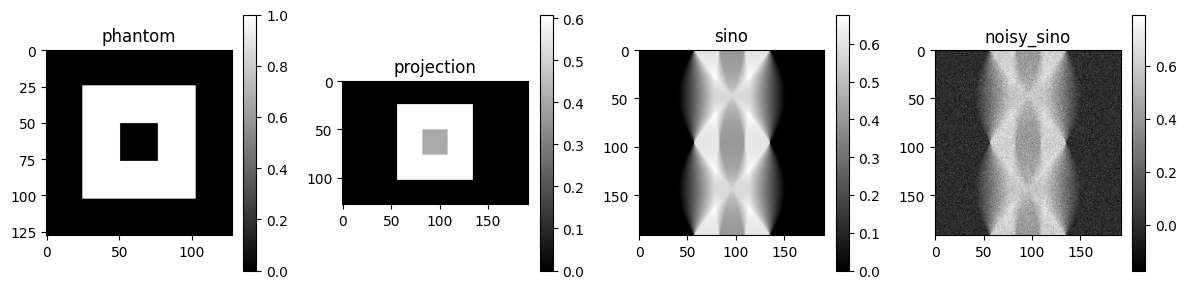

In [5]:
# set N (number of pixels in each dimension)
N = 128

# Create volume geometry of a unit cube on the origin with N pixels in each dimension
full_vg = ts.volume(size=1, shape=N)

# Projection geometry with 3N/2 angles and 3N/2 pixels per angle giving 1.5 units width and 1 unit height
full_pg = ts.parallel(angles=3 * N // 2, shape=(N, 3 * N // 2), size=(1, 1.5))

# Create the forward operator
A = ts.operator(full_vg, full_pg)

# Create a phantom
phantom = ts.phantom.hollow_box(ts.data(full_vg)).data

# convert phantom to torch tensor
phantom = torch.from_numpy(phantom)

# apply forward operator to phantom to get sinogram
sino = A(phantom)

# add noise to sinogram
noisy_sino = sino + sino.max() / 20 * torch.randn_like(sino)

# plot images
plot_imgs(
    phantom=phantom[64],                # central axial slice
    projection=sino[:, 0, :],           # first projection image
    sino=sino[64, ...],                 # sinogram of central slice
    noisy_sino=noisy_sino[64, ...],     # noisy sinogram
)

### Naive SIRT implementation (GPU)

We implement SIRT directly from the formula, using PyTorch tensors on GPU. 

This is done because creating tensors on GPU avoids ASTRA moving data between CPU and GPU which roughly doubles the performance.

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 82.58it/s]


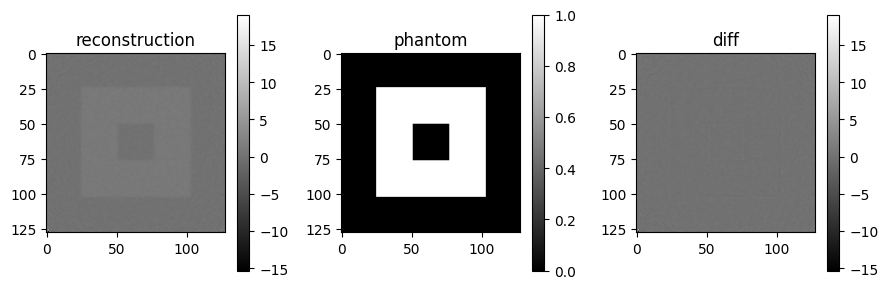

In [6]:
# select device
dev = torch.device("cuda")

# set number of iterations
num_iters = 100

# move noisy sinogram to device
y = noisy_sino.to(dev)
# initialise reconstruction with zeros
x_cur = torch.zeros(A.domain_shape, device=dev)

# compute C for SIRT - same as backprojection of a vector of ones
C = A.T(torch.ones(A.range_shape, device=dev))
C[C < ts.epsilon] = np.inf

# reciprocal avoids division by zero
C.reciprocal_()

# compute R for SIRT - same as forward projection of a vector of ones
R = A(torch.ones(A.domain_shape, device=dev))
R[R < ts.epsilon] = np.inf

# reciprocal avoids division by zero
R.reciprocal_()

# formula for SIRT
for i in tqdm(range(num_iters)):
    x_cur += C * A.T(R * (y - A(x_cur)))

# plot images for reconstruction, phantom and difference between them
plot_imgs(
    reconstruction=x_cur[64],
    phantom=phantom[64],
    diff = (x_cur.cpu() - phantom)[64],
)

### Optimised SIRT with residual tracking

This version avoids allocating intermediate tensors (useful near the GPU memory limit) and tracks the residual $\|Ax - y\|^2$ at each iteration to monitor convergence.

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 59.39it/s]


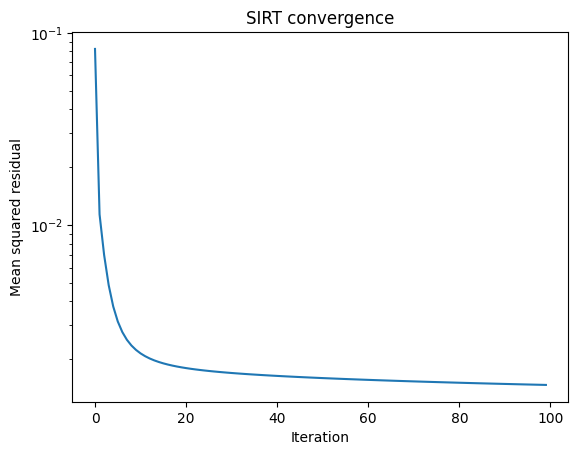

In [7]:
# define C
y_tmp = torch.ones(A.range_shape, device=dev)
C = A.T(y_tmp)
C[C < ts.epsilon] = np.inf
C.reciprocal_()

# define R
x_tmp = torch.ones(A.domain_shape, device=dev)
R = A(x_tmp)
R[R < ts.epsilon] = np.inf
R.reciprocal_()

# initialise reconstruction with zeros
y = noisy_sino.to(dev)
x_cur = torch.zeros(A.domain_shape, device=dev)

# calculate residuals at each iteration
residuals = np.zeros(num_iters)

# loop over iterations
for i in tqdm(range(num_iters)):

    # projection of current reconstruction
    A(x_cur, out=y_tmp)

    # flip sign to get residual in projection space
    y_tmp -= y   

    # keep track of residual error in projection data
    residuals[i] = torch.square(y_tmp).mean()

    # backproject residual, scale by R and C and update reconstruction
    y_tmp *= R
    A.T(y_tmp, out=x_tmp)
    x_tmp *= C
    x_cur -= x_tmp # flip sign here

# plot residuals
plt.plot(residuals)
plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Mean squared residual")
plt.title("SIRT convergence")
plt.show()

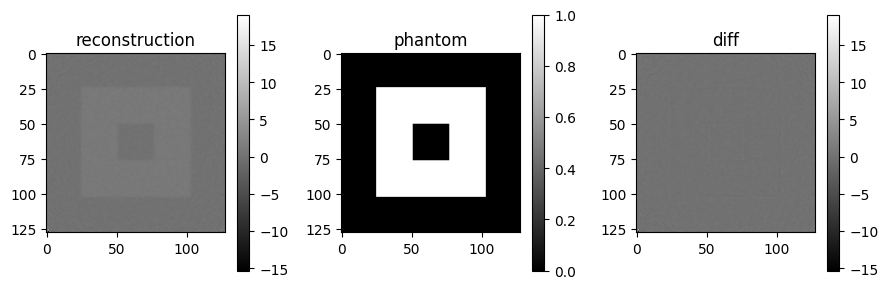

In [8]:
# plot images for reconstruction, phantom and difference between them
plot_imgs(
    reconstruction=x_cur[64],
    phantom=phantom[64],
    diff=(x_cur.cpu() - phantom)[64],
)

### Validation against ASTRA's internal SIRT

To verify that the manual implementation produces the same result, we run ASTRA's built-in `SIRT3D_CUDA`, confirming that the tomosipo operator interface correctly wraps the ASTRA backend.

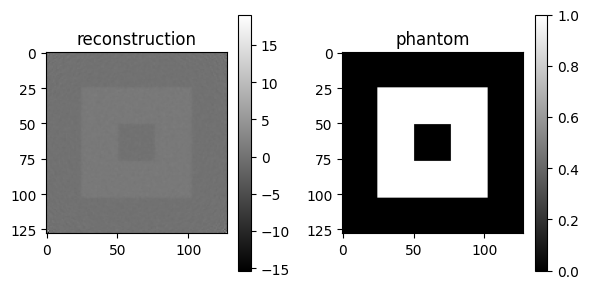

In [9]:
# define volume data 
vd = ts.data(full_vg)

# define projection data
pd = ts.data(full_pg, noisy_sino)

with vd, pd:

    # convert reconstruction data to astra data object
    rec_id = vd.to_astra()

    # convert projection data to astra data object
    sinogram_id = pd.to_astra()

    # create configuration for SIRT algorithm
    cfg = astra.astra_dict('SIRT3D_CUDA')

    # set the data ids in the configuration
    cfg['ReconstructionDataId'] = rec_id
    cfg['ProjectionDataId'] = sinogram_id

    # Create the algorithm object from the configuration structure
    alg_id = astra.algorithm.create(cfg)
    astra.algorithm.run(alg_id, num_iters)

    # Make copy of the reconstruction
    astra_rec = torch.from_numpy(np.copy(vd.data))

    # Delete algorithm
    astra.algorithm.delete(alg_id)

# plot images for reconstruction and phantom
plot_imgs(
    reconstruction=astra_rec[64],
    phantom=phantom[64],
)

Comparing the difference between the manual implementation and ASTRA'S built in version shows that the difference between the two is negligible.

In [10]:
# The difference between the two implementations is negligible :)
print("Mean absolute difference:", abs(astra_rec - x_cur.cpu()).mean().item())

Mean absolute difference: 2.892485539973677e-08


# Section 2 — Project-Specific Exploration

This section adapts tomosipo tools to match the TFPnP paper's experimental setup:

- **Geometry**: 2D parallel-beam
- **Resolution**: 256×256
- **Views**: 24x dosage reduction, so we compare a 30 (sparse) and 720 (full) number of views
- **Phantom**: Shepp-Logan Phantom to simulate a standard CT test image
- **Noise**: Gaussian at 5%, 7.5%, 10%
- **Metrics**: PSNR and SSIM

### Why these choices matter

As LION is based on Tomosipo and astra, it is important to confirm that the setup of the paper can be replicated exactly with these tools. The Shepp-Logan phantom models the structures of a CT image to test whether a reconstruction algorithm can handle this well, and Gaussian noise is used because after the log-transform of Poisson photon counts, sinogram noise is approximately Gaussian.

### Checklist (from Ander's email)

By the end of this section, we should be able to:
1. ✅ Define a CT geometry in tomosipo
2. ✅ Forward project an arbitrary image
3. ✅ Add noise
4. ✅ Reconstruct using ts_algorithms (FBP, SIRT, NAG_LS, TV-min)
5. ✅ Compute PSNR and SSIM

## 2.1 Geometry Definition

### CT Beam Geometries

In CT, the **beam geometry** describes the shape and direction of the X-ray beams as they pass through the object and reach the detector.

Different beam geometries collect projection data in different ways, which affects how the reconstruction is performed.

- In **parallel-beam CT**, the X-rays travel in straight, parallel lines through the object, so for each projection angle, all rays pass through the object in the same direction. It is often used in theory and simulations, and is closely linked to the Radon transform and Fourier Slice Theorem. Despite this, x-rays usually come from a finite source and therefore naturally spread out, so parallel-beam is not common in real clinical settings.
- In **fan-beam CT**, the X-rays come from a single point source and spread out in a flat fan shape, covering a 2D slice of the object, and the detector records the rays after they pass through that slice. This is more realistic than parallel-beam as it represents how many standard scanner collect data, with the source and detector rotating around the object taking projections from many angles. It is mainly used for reconstructing 2D slices
- In **cone-beam CT**, the X-rays also come from a single point source, but instead of spreading out only in a flat fan, they spread out in a full cone shape, allowing the scanner to capture a 2D projection of a 3D object at each angle. This is used when reconstrcting the full 3D volume of an object, and is common in dental imaging and other specialised CT systems. Come-beam is efficient as it collects a lot of data at once, however the reconstruction is more complex due to rays diverging in both horizontal and vertical directions.
- In **pencil-beam geometry**, a very narrow beam of X-rays passes through the object one line at a time, meaning that the beam has to scan across the object to build up a full projection. This method, despite beign simple conceptually, is very slow compared to others and is less common in modern imaging.

### Project specific goemetry

The notebook defines two geometries, following the paper:

- **Full-view** (720 angles): the clinical standard, used as reference
- **Sparse-view** (30 angles): 24× dosage reduction, the TFPnP test setting

The image resolution is 256×256. Tomosipo requires 3D volumes, so we use depth=1 for the 2D case.

In [11]:
# import libraries
import numpy as np
import torch
import tomosipo as ts
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from timeit import default_timer as timer
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
import ts_algorithms as tsa

# set image resolution to be the same as TFPnP paper
N = 256 

# add depth=1 to make the 2D image suitable for tomosipo
vg = ts.volume(shape=(1, N, N))

# initialise full view geometry
pg_full = ts.parallel(angles=720, shape=(1, N))
A_full = ts.operator(vg, pg_full)

# initialise sparse view geometry (24x reduction)
pg_sparse = ts.parallel(angles=30, shape=(1, N))
A_sparse = ts.operator(vg, pg_sparse)

# print shapes of domain and range
print("Full-view  — Domain:", A_full.domain_shape, " Range:", A_full.range_shape)
print("Sparse-view — Domain:", A_sparse.domain_shape, "Range:", A_sparse.range_shape)

Full-view  — Domain: (1, 256, 256)  Range: (1, 720, 256)
Sparse-view — Domain: (1, 256, 256) Range: (1, 30, 256)


## 2.2 Phantom

The Shepp-Logan phantom is used as the standard test image for CT reconstruction.

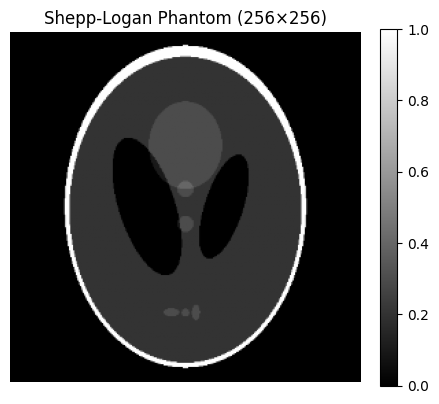

Phantom shape: (1, 256, 256)
Value range: [0.000, 1.000]


In [12]:
# load Shepp-Logan phantom
phantom_2d = shepp_logan_phantom()

# resize to (256, 256) and convert to float32 for stability
phantom_2d = resize(phantom_2d, (N, N), anti_aliasing=True).astype(np.float32)

# Add depth dimension (Tomosipo needs (1, H, W) shape)
phantom = phantom_2d[np.newaxis, :, :]

# Plot Phantom
plt.figure(figsize=(5, 5))

# ensure greyscale
plt.imshow(phantom[0], cmap="gray")

# add title and colorbar
plt.title("Shepp-Logan Phantom (256×256)")
plt.colorbar(fraction=0.046)
plt.axis("off")

# save figure and show
plt.savefig("../figures/01/01_phantom.pdf", bbox_inches="tight")
plt.show()

# print shape and value range
print("Phantom shape:", phantom.shape)
print("Value range: [{:.3f}, {:.3f}]".format(phantom.min(), phantom.max()))

## 2.3 Forward Projection (Sinogram Generation)

Sinograms are computed using both the full-view and sparse-view operators:

$$y_{\text{full}} = A_{\text{full}} \, x, \qquad y_{\text{sparse}} = A_{\text{sparse}} \, x$$

The full sinogram has 720 rows (one per angle), whereas the sparse sinogram has only 30 resulting in a reconstruction where most of the angular information is missing, making the problem much harder.

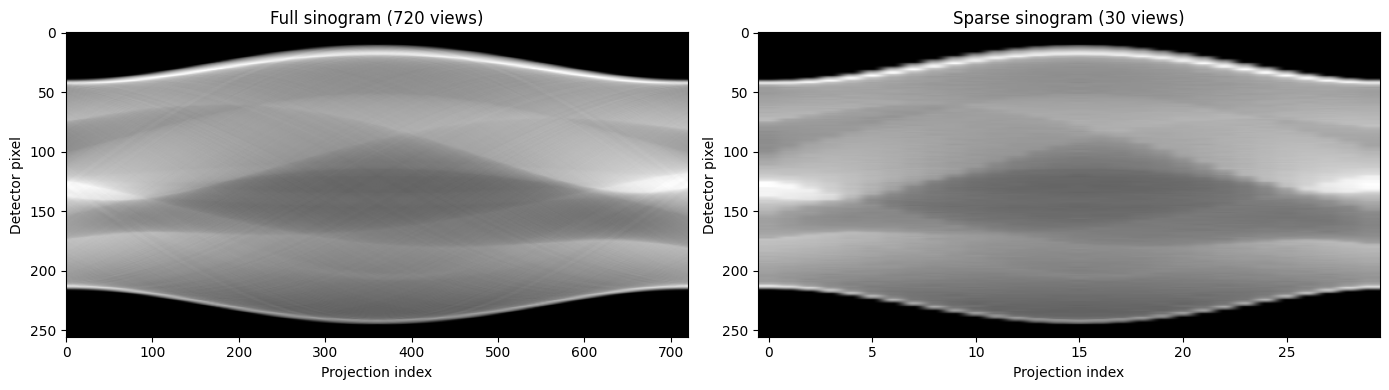

Full sinogram shape:   (720, 256)
Sparse sinogram shape: (30, 256)


In [13]:
# Define forward projections
y_full = A_full(phantom)
y_sparse = A_sparse(phantom)

# plot sinograms
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# convert sinograms to numpy and squeeze to remove depth dimension
sino_full_img = y_full.squeeze()
sino_sparse_img = y_sparse.squeeze()

# plot full and sparse sinograms side by side
axes[0].imshow(sino_full_img.T, cmap="gray", aspect='auto')
axes[0].set_title("Full sinogram (720 views)")
axes[0].set_xlabel("Projection index")
axes[0].set_ylabel("Detector pixel")

axes[1].imshow(sino_sparse_img.T, cmap="gray", aspect='auto')
axes[1].set_title("Sparse sinogram (30 views)")
axes[1].set_xlabel("Projection index")
axes[1].set_ylabel("Detector pixel")

# save figure and show
plt.tight_layout()
plt.savefig("../figures/01/02_sinograms.pdf", dpi=150, bbox_inches="tight")
plt.show()

# print shapes of sinograms
print(f"Full sinogram shape:   {sino_full_img.shape}")
print(f"Sparse sinogram shape: {sino_sparse_img.shape}")

We can see that the sparse view sinogram is stretched by the aspect ratio (auto) to match the full view. It is clear however, that the sinogram itself is of much worse quality, which is particularly visible at the edges, where a lot of blurring is present.

## 2.4 Adding Gaussian Noise

The TFPnP paper adds Gaussian noise to the sinogram at three levels: $\sigma \in \{5\%, 7.5\%, 10\%\}$, simulating low-dose acquisition, however for this notebook, the $5\%$ case is explored.

#### Why Gaussian and not Poisson?

 In physical CT, the raw photon counts follow a Poisson distribution. However, after the log-transform (Beer-Lambert law), the noise becomes approximately Gaussian for moderate dose levels. The TFPnP paper adds Gaussian noise directly to the log-transformed sinogram, and we follow the same convention for consistency.

In [14]:
# set noise level
noise_level = 0.05

# add noise using NumPy, because y_full and y_sparse are NumPy arrays
np.random.seed(42)
y_sparse_noisy = y_sparse + noise_level * np.random.randn(*y_sparse.shape).astype(np.float32)
y_full_noisy   = y_full   + noise_level * np.random.randn(*y_full.shape).astype(np.float32)

# convert to torch tensors for ts_algorithms
y_sparse_noisy = torch.from_numpy(y_sparse_noisy).float().cuda()
y_full_noisy   = torch.from_numpy(y_full_noisy).float().cuda()

# print results for confirmation
print(f"Noise level: {noise_level*100:.1f}%")
print(f"Noisy sparse sinogram shape: {y_sparse_noisy.shape}")
print(f"Noisy full sinogram shape: {y_full_noisy.shape}")

Noise level: 5.0%
Noisy sparse sinogram shape: torch.Size([1, 30, 256])
Noisy full sinogram shape: torch.Size([1, 720, 256])


## 2.5 Reconstruction with ts_algorithms

The sparse and full views are reconstructed using four classical algorithms, all available in `ts_algorithms`:

| Method | Type | Key property |
|--------|------|--------------|
| **FBP** | Analytic | Fast, exact with full views, but amplifies noise via ramp filter |
| **SIRT** | Iterative (least-squares) | Handles missing data better than FBP, but slow and no regularisation |
| **NAG_LS** | Accelerated iterative | Faster convergence than SIRT via Nesterov momentum |
| **TV-min** | Regularised (total variation) | Promotes piecewise-constant images, suppresses noise, but introduces staircase artefacts |

In [15]:
# set hyperparameters
num_iters = 100
tv_lambda = 0.01

# FBP full view
start = timer()
x_fbp_full = tsa.fbp(A_full, y_full_noisy)
fbp_full_time = timer() - start
print(f"FBP (720 views) done in {fbp_full_time:.2f} s")

# FBP sparse view
start = timer()
x_fbp_sparse = tsa.fbp(A_sparse, y_sparse_noisy)
fbp_sparse_time = timer() - start
print(f"FBP (30 views)  done in {fbp_sparse_time:.2f} s")

# SIRT full view
start = timer()
x_sirt_full = tsa.sirt(A_full, y_full_noisy, num_iterations=num_iters)
sirt_full_time = timer() - start
print(f"SIRT (720 views) done in {sirt_full_time:.2f} s")

# SIRT sparse view
start = timer()
x_sirt_sparse = tsa.sirt(A_sparse, y_sparse_noisy, num_iterations=num_iters)
sirt_sparse_time = timer() - start
print(f"SIRT (30 views) done in {sirt_sparse_time:.2f} s")

# NAG_LS full view
start = timer()
x_nag_full = tsa.nag_ls(A_full, y_full_noisy, num_iterations=num_iters)
nag_full_time = timer() - start
print(f"NAG_LS (720 views) done in {nag_full_time:.2f} s")

# NAG_LS sparse view
start = timer()
x_nag_sparse = tsa.nag_ls(A_sparse, y_sparse_noisy, num_iterations=num_iters)
nag_sparse_time = timer() - start
print(f"NAG_LS (30 views) done in {nag_sparse_time:.2f} s")

# TV minimisation full view
start = timer()
x_tv_full = tsa.tv_min.tv_min2d(A_full, y_full_noisy, num_iterations=num_iters, lam=tv_lambda)
tv_full_time = timer() - start
print(f"TV-min (720 views) done in {tv_full_time:.2f} s")

# TV minimisation sparse view
start = timer()
x_tv_sparse = tsa.tv_min.tv_min2d(A_sparse, y_sparse_noisy, num_iterations=num_iters, lam=tv_lambda)
tv_sparse_time = timer() - start
print(f"TV-min (30 views) done in {tv_sparse_time:.2f} s")

FBP (720 views) done in 1.62 s
FBP (30 views)  done in 0.00 s
SIRT (720 views) done in 0.31 s
SIRT (30 views) done in 0.24 s
NAG_LS (720 views) done in 0.58 s
NAG_LS (30 views) done in 0.26 s
TV-min (720 views) done in 8.83 s
TV-min (30 views) done in 0.66 s


## 2.6 Quantitative Evaluation (PSNR and SSIM)

Reconstruction quality is evaluated using the same metrics as the TFPnP paper:

- **PSNR** (Peak Signal-to-Noise Ratio): measures pixel-level accuracy in dB. Higher is better.
- **SSIM** (Structural Similarity Index): measures perceptual similarity. Ranges from 0 to 1; higher is better.

In [16]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# helper function to compute PSNR and SSIM
def compute_metrics(recon, gt):

    """Compute PSNR and SSIM between reconstruction and ground truth."""

    recon = recon.detach().cpu().numpy().squeeze()
    gt = gt.squeeze()
    
    data_range = gt.max() - gt.min()
    p = psnr(gt, recon, data_range=data_range)
    s = ssim(gt, recon, data_range=data_range)
    return p, s

# convert phantom to numpy and squeeze to remove depth dimension
gt = phantom.squeeze()

# define dictionary of methods and reconstructions
methods = {
    "FBP (720 views)":  x_fbp_full,
    "FBP (30 views)":   x_fbp_sparse,
    "SIRT (720 views)":  x_sirt_full,
    "SIRT (30 views)":  x_sirt_sparse,
    "NAG_LS (720 views)": x_nag_full,
    "NAG_LS (30 views)": x_nag_sparse,
    "TV-min (720 views)": x_tv_full,
    "TV-min (30 views)": x_tv_sparse,
}

# compute and print metrics for each method
print(f"\n{'Method':<22} {'PSNR (dB)':>10} {'SSIM':>8}")
print("-" * 42)
for name, recon in methods.items():
    p, s = compute_metrics(recon, gt)
    print(f"{name:<22} {p:>10.2f} {s:>8.4f}")


Method                  PSNR (dB)     SSIM
------------------------------------------
FBP (720 views)             29.35   0.7821
FBP (30 views)              17.30   0.2953
SIRT (720 views)            26.36   0.8992
SIRT (30 views)             20.89   0.4409
NAG_LS (720 views)          36.20   0.9171
NAG_LS (30 views)           21.35   0.4377
TV-min (720 views)          18.91   0.7157
TV-min (30 views)           18.90   0.7149


## 2.7 Visual Comparison

Plotting a reconstruction grid provides a side-by-side comparison of all methods, directly corresponding to Figures 2.3/2.4 in the report.

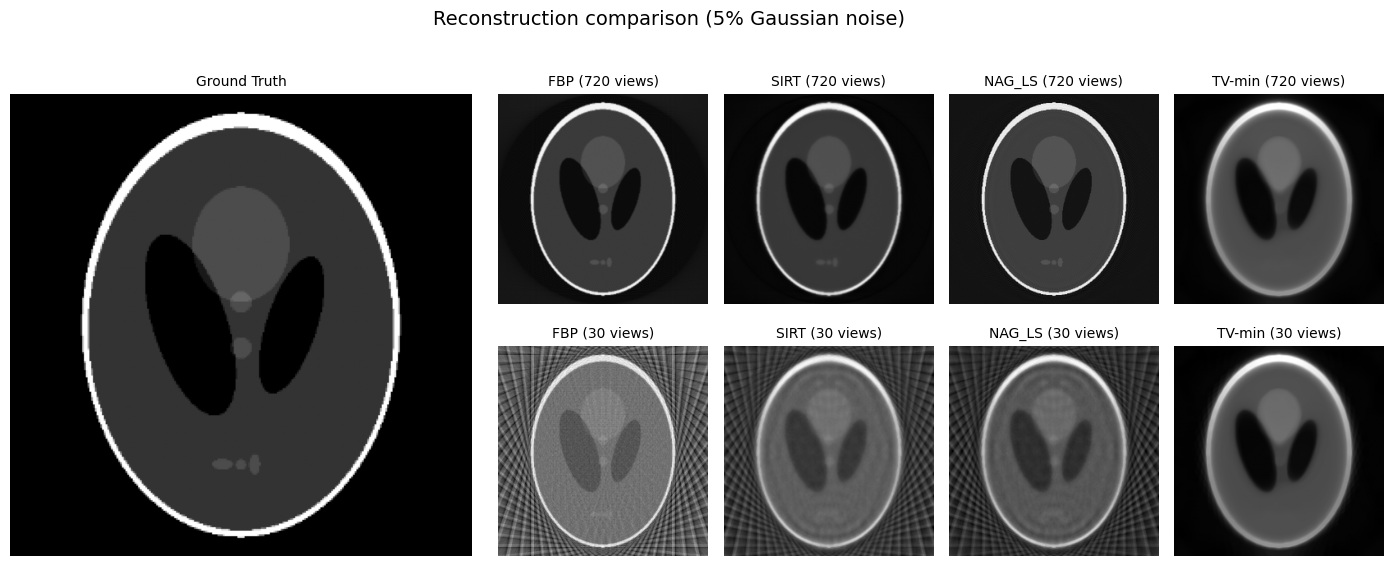

In [17]:
fig = plt.figure(figsize=(18, 6))

gs = gridspec.GridSpec(2, 5, width_ratios=[2.25, 1, 1, 1, 1], wspace=0.02, hspace=0.2)

# Ground truth — large panel spanning both rows
ax_gt = fig.add_subplot(gs[:, 0])
ax_gt.imshow(phantom.squeeze(), cmap="gray")
ax_gt.set_title("Ground Truth", fontsize=10)
ax_gt.axis("off")

# 720-view row (top)
recons_720 = [
    (x_fbp_full.detach().cpu().numpy().squeeze(),  "FBP (720 views)"),
    (x_sirt_full.detach().cpu().numpy().squeeze(), "SIRT (720 views)"),
    (x_nag_full.detach().cpu().numpy().squeeze(),  "NAG_LS (720 views)"),
    (x_tv_full.detach().cpu().numpy().squeeze(),   "TV-min (720 views)"),
]

for i, (img, name) in enumerate(recons_720):
    ax = fig.add_subplot(gs[0, i + 1])
    ax.imshow(img, cmap="gray")
    ax.set_title(name, fontsize=10)
    ax.axis("off")

# 30-view row (bottom)
recons_30 = [
    (x_fbp_sparse.detach().cpu().numpy().squeeze(),  "FBP (30 views)"),
    (x_sirt_sparse.detach().cpu().numpy().squeeze(), "SIRT (30 views)"),
    (x_nag_sparse.detach().cpu().numpy().squeeze(),  "NAG_LS (30 views)"),
    (x_tv_sparse.detach().cpu().numpy().squeeze(),   "TV-min (30 views)"),
]

for i, (img, name) in enumerate(recons_30):
    ax = fig.add_subplot(gs[1, i + 1])
    ax.imshow(img, cmap="gray")
    ax.set_title(name, fontsize=10)
    ax.axis("off")

plt.suptitle(f"Reconstruction comparison ({noise_level*100:.0f}% Gaussian noise)", fontsize=14, y=1.02)
plt.savefig("../figures/01/03_recon_comparison.pdf", dpi=150, bbox_inches="tight")
plt.show()

## 2.8 Difference Maps

Difference maps show $|\hat{x} - x^*|$, which is the pixel-wise error between each reconstruction and the ground truth, which demonstrates that:

- **FBP**: structured streak artefacts (correlated error)
- **SIRT**: diffuse error, concentrated at edges
- **TV-min**: low error overall but sharp transitions at edges (staircase effect)

This figure corresponds to report Figure 2.3 (difference maps).

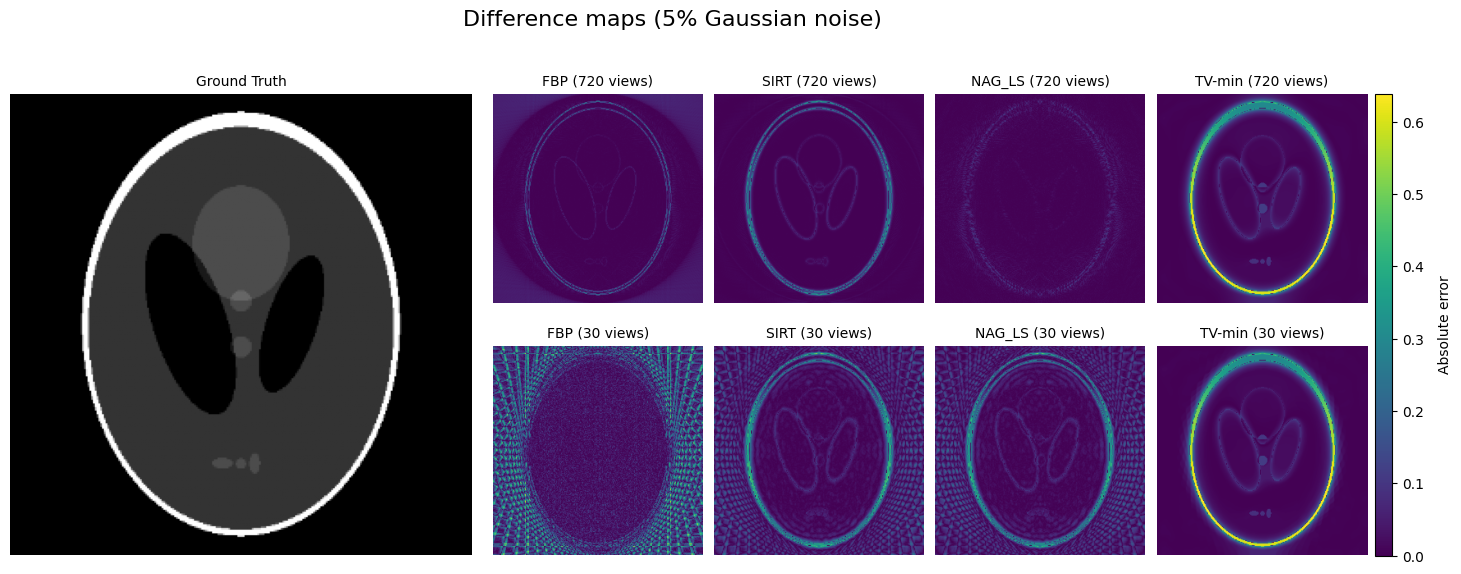

In [18]:
fig = plt.figure(figsize=(18, 6))

# Add an extra column for the colourbar
gs = gridspec.GridSpec(2, 6, width_ratios=[2.25, 1, 1, 1, 1, 0.08], wspace=0.02, hspace=0.2)

# Ground truth — large panel spanning both rows
ax_gt = fig.add_subplot(gs[:, 0])
ax_gt.imshow(phantom.squeeze(), cmap="gray")
ax_gt.set_title("Ground Truth", fontsize=10)
ax_gt.axis("off")

# Compute all difference maps
diffs_720 = [
    (x_fbp_full.detach().cpu().numpy().squeeze()  - gt, "FBP (720 views)"),
    (x_sirt_full.detach().cpu().numpy().squeeze() - gt, "SIRT (720 views)"),
    (x_nag_full.detach().cpu().numpy().squeeze()  - gt, "NAG_LS (720 views)"),
    (x_tv_full.detach().cpu().numpy().squeeze()   - gt, "TV-min (720 views)"),
]

diffs_30 = [
    (x_fbp_sparse.detach().cpu().numpy().squeeze()  - gt, "FBP (30 views)"),
    (x_sirt_sparse.detach().cpu().numpy().squeeze() - gt, "SIRT (30 views)"),
    (x_nag_sparse.detach().cpu().numpy().squeeze()  - gt, "NAG_LS (30 views)"),
    (x_tv_sparse.detach().cpu().numpy().squeeze()   - gt, "TV-min (30 views)"),
]

vmax = max(
    max(np.abs(d[0]).max() for d in diffs_720),
    max(np.abs(d[0]).max() for d in diffs_30)
)

for i, (diff, name) in enumerate(diffs_720):
    ax = fig.add_subplot(gs[0, i + 1])
    ax.imshow(np.abs(diff), cmap="viridis", vmin=0, vmax=vmax)
    ax.set_title(name, fontsize=10)
    ax.axis("off")

for i, (diff, name) in enumerate(diffs_30):
    ax = fig.add_subplot(gs[1, i + 1])
    im = ax.imshow(np.abs(diff), cmap="viridis", vmin=0, vmax=vmax)
    ax.set_title(name, fontsize=10)
    ax.axis("off")

# Colourbar in its own grid column — automatically aligned with the rows
cbar_ax = fig.add_subplot(gs[:, 5])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Absolute error", labelpad=10)

plt.suptitle(f"Difference maps ({noise_level*100:.0f}% Gaussian noise)", fontsize=16, y=1.02)
plt.savefig("../figures/01/04_difference_maps.pdf", dpi=150, bbox_inches="tight")
plt.show()

## 2.9 Timing Summary

In [19]:
print("Timing Summary:")
print(f"  FBP    (720 views): {fbp_full_time:.2f} s")
print(f"  FBP    (30 views) : {fbp_sparse_time:.2f} s")
print(f"  SIRT   (720 views): {sirt_full_time:.2f} s ({num_iters} iters)")
print(f"  SIRT   (30 views) : {sirt_sparse_time:.2f} s ({num_iters} iters)")
print(f"  NAG_LS (720 views): {nag_full_time:.2f} s ({num_iters} iters)")
print(f"  NAG_LS (30 views) : {nag_sparse_time:.2f} s ({num_iters} iters)")
print(f"  TV-min (720 views): {tv_full_time:.2f} s ({num_iters} iters)")
print(f"  TV-min (30 views) : {tv_sparse_time:.2f} s ({num_iters} iters)")

Timing Summary:
  FBP    (720 views): 1.62 s
  FBP    (30 views) : 0.00 s
  SIRT   (720 views): 0.31 s (100 iters)
  SIRT   (30 views) : 0.24 s (100 iters)
  NAG_LS (720 views): 0.58 s (100 iters)
  NAG_LS (30 views) : 0.26 s (100 iters)
  TV-min (720 views): 8.83 s (100 iters)
  TV-min (30 views) : 0.66 s (100 iters)


## 2.10 Multi-Noise-Level Comparison

The TFPnP paper tests at three noise levels (5%, 7.5%, 10%), so running the full baseline comparison at all three establishes the performance landscape that TFPnP must improve upon.

In [20]:
noise_levels = [0.05, 0.075, 0.10]
results = {}

# calculate reconstructions across different noise levels
for sigma in noise_levels:
    np.random.seed(42)
    y_n = y_sparse + sigma * np.random.randn(*y_sparse.shape).astype(np.float32)
    y_n = torch.from_numpy(y_n).float().cuda()

    x_fbp_s = tsa.fbp(A_sparse, y_n)
    x_sirt_s = tsa.sirt(A_sparse, y_n, num_iterations=num_iters)
    x_tv_s = tsa.tv_min.tv_min2d(A_sparse, y_n, num_iterations=num_iters, lam=tv_lambda)

    results[sigma] = {}
    for name, recon in [("FBP", x_fbp_s), ("SIRT", x_sirt_s), ("TV-min", x_tv_s)]:
        p, s = compute_metrics(recon, gt)
        results[sigma][name] = (p, s)

# Print results table

# set width for consistency
col_width = 14
print(f"\n{'Method':<12}", end="")
for sigma in noise_levels:
    print(f"{f'{sigma*100:.1f}% PSNR':>{col_width}}{f'{sigma*100:.1f}% SSIM':>{col_width}}", end="")
print()

print("-" * (12 + 2 * col_width * len(noise_levels)))

for method in ["FBP", "SIRT", "TV-min"]:
    print(f"{method:<12}", end="")
    for sigma in noise_levels:
        p, s = results[sigma][method]
        print(f"{p:>{col_width}.2f}{s:>{col_width}.4f}", end="")
    print()
print("-" * (12 + 2 * col_width * len(noise_levels)))


Method           5.0% PSNR     5.0% SSIM     7.5% PSNR     7.5% SSIM    10.0% PSNR    10.0% SSIM
------------------------------------------------------------------------------------------------
FBP                  17.30        0.2953         17.29        0.2930         17.27        0.2899
SIRT                 20.89        0.4409         20.89        0.4405         20.89        0.4400
TV-min               18.90        0.7149         18.90        0.7149         18.90        0.7148
------------------------------------------------------------------------------------------------


## Summary

This notebook has established:

1. **Tomosipo works correctly**: manual SIRT matches ASTRA's internal implementation
2. **Parallel-beam geometry replicates the paper setup**: 30-view, 256×256 resolution
3. **Baseline performance is quantified**: FBP, SIRT, and TV-min PSNR/SSIM at all three noise levels

### Output files for the report
- `sinogram_comparison.pdf` → Figure 2.2 (sinograms)
- `reconstruction_comparison.pdf` → Figure 2.3 (reconstruction grid)
- `difference_maps.pdf` → Figure 2.3 (difference maps)